In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [16]:
clientes = pd.read_csv('./creditos.csv')
clientes

,edad,credito,cumplio
0,18,363112,0
1,19,477965,1
2,20,239072,0
3,22,195265,0
4,22,482174,0
...,...,...,...
195,55,100000,0
196,55,523144,0
197,55,543771,0
198,56,285288,0


In [17]:
paga = clientes[clientes["cumplio"]==1]
no_paga = clientes[clientes["cumplio"]==0]

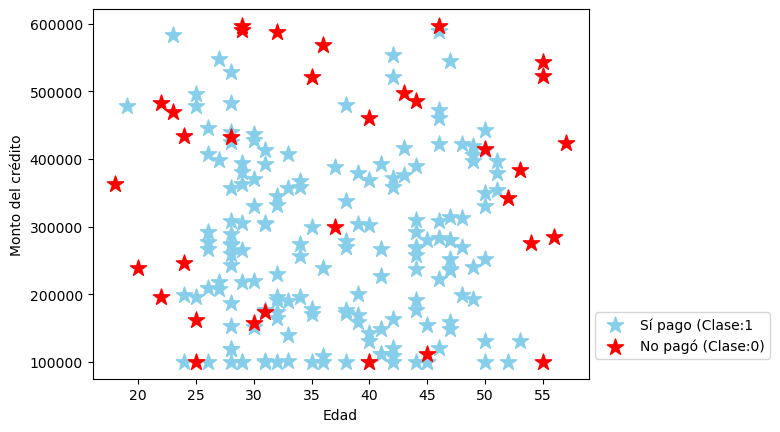

In [18]:
plt.scatter(paga["edad"],paga["credito"],
           marker="*", s=150, color="skyblue",
           label = "Sí pago (Clase:1")

plt.scatter(no_paga["edad"], no_paga["credito"],
           marker="*", s=150, color="red",
           label="No pagó (Clase:0)")

plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.2))
plt.show()

In [19]:
#Preprocesamiento de los datos (escalar)
datos = clientes[["edad","credito"]]
clase = clientes["cumplio"]

escalador = preprocessing.MinMaxScaler()

datos = escalador.fit_transform(datos)
print(datos)

[[0.         0.52964444]
 [0.02564103 0.76084353]
 [0.05128205 0.27995193]
 [0.1025641  0.19176844]
 [0.1025641  0.76931624]
 [0.12820513 0.74242458]
 [0.12820513 0.97341632]
 [0.15384615 0.        ]
 [0.15384615 0.19983453]
 [0.15384615 0.29429053]
 [0.15384615 0.67122276]
 [0.17948718 0.        ]
 [0.17948718 0.12374716]
 [0.17948718 0.19192143]
 [0.17948718 0.76130249]
 [0.17948718 0.79673129]
 [0.20512821 0.        ]
 [0.20512821 0.21862589]
 [0.20512821 0.33577846]
 [0.20512821 0.35571521]
 [0.20512821 0.38628463]
 [0.20512821 0.61926119]
 [0.20512821 0.69480706]
 [0.23076923 0.21664509]
 [0.23076923 0.23805134]
 [0.23076923 0.60140789]
 [0.23076923 0.90058196]
 [0.25641026 0.        ]
 [0.25641026 0.03816245]
 [0.25641026 0.03904616]
 [0.25641026 0.10798336]
 [0.25641026 0.17607107]
 [0.25641026 0.28867627]
 [0.25641026 0.32202564]
 [0.25641026 0.3484986 ]
 [0.25641026 0.35193882]
 [0.25641026 0.38080524]
 [0.25641026 0.42070089]
 [0.25641026 0.51803547]
 [0.25641026 0.65311582]


In [20]:
clasificador = KNeighborsClassifier(n_neighbors = 3)
clasificador.fit(datos,clase)

KNeighborsClassifier(n_neighbors=3)

Clase: [0]
Probabilidades por clase [[0.66666667 0.33333333]]


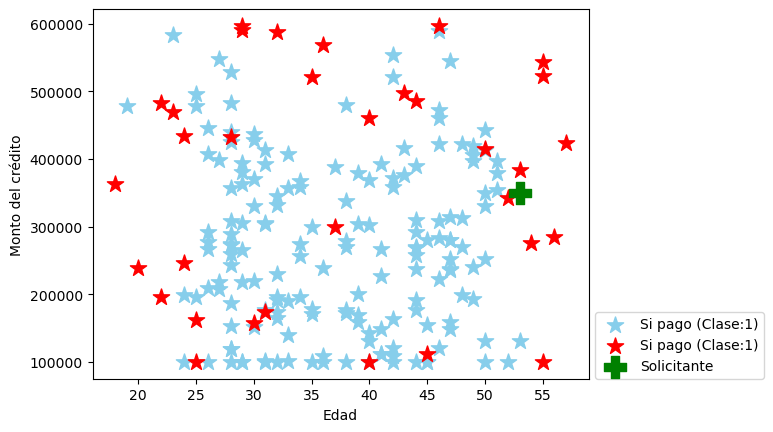

In [21]:
#Clasificar al nuevo solicitante

edad=53
monto=350000

#Escalar los datos del nuevo solicitante
solicitante = escalador.transform([[edad, monto]])

print("Clase:", clasificador.predict(solicitante))
print("Probabilidades por clase", clasificador.predict_proba(solicitante))

plt.scatter(paga["edad"], paga["credito"],
           marker="*", s=150, color="skyblue", label="Si pago (Clase:1)")

plt.scatter(no_paga["edad"], no_paga["credito"],
           marker="*", s=150, color="red", label="Si pago (Clase:1)")

plt.scatter(edad, monto, marker="P", s=250, color="green", label="Solicitante")

plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.2))
plt.show()

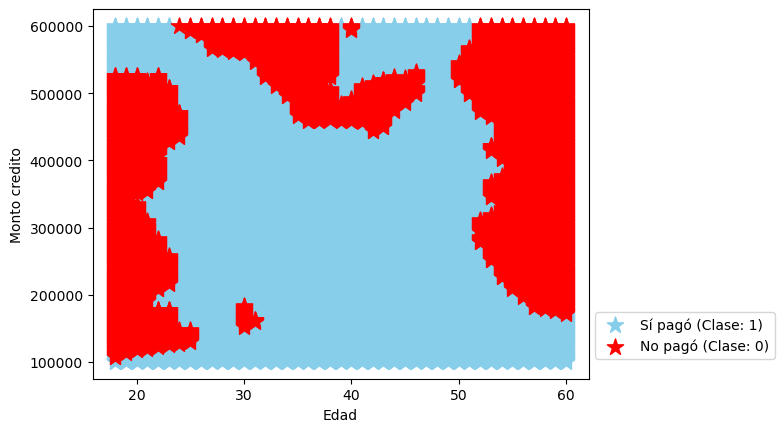

In [22]:
#Regiones de la clase
#Datos sintéticos de todos los posibles solicitantes
creditos = np.array([np.arange(100000, 600010, 1000)]*43).reshape(1, -1)
edades = np.array([np.arange(18, 61)]*501).reshape(1, -1)
todos = pd.DataFrame(np.stack((edades, creditos), axis=2)[0],
                     columns=["edad", "credito"])

#Escalar los datos del nuevo solicitante
solicitantes = escalador.transform(todos)

#predecir todas las clases
clases_resultantes = clasificador.predict(solicitantes)

#Codigo para graficar
paga = todos[clases_resultantes==1]
no_paga = todos[clases_resultantes==0]
plt.scatter(paga["edad"], paga["credito"],
            marker="*", s=150, color="skyblue",
            label="Sí pagó (Clase: 1)")

plt.scatter(no_paga["edad"], no_paga["credito"],
            marker="*", s=150, color="red",
            label="No pagó (Clase: 0)")
plt.ylabel("Monto credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()

### ¿Cómo elegir K?

0.3
-1.1774632553075661


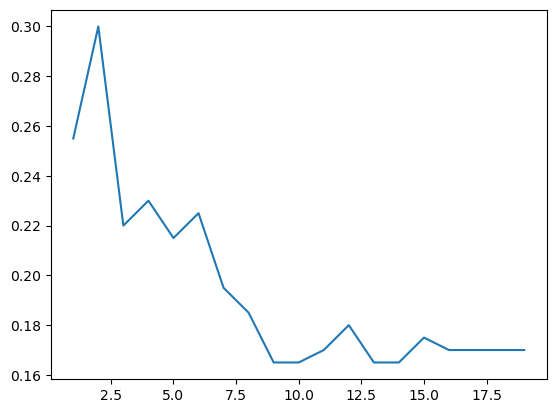

In [23]:
clasificador = KNeighborsClassifier(n_neighbors=2)
y_pred = cross_val_predict(clasificador, datos, clase, cv=5)

print(mean_squared_error(clase, y_pred))
print(r2_score(clase,y_pred))

error=[]
for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    y_pred=cross_val_predict(knn,datos,clase,cv=5)
    error.append(mean_squared_error(clase,y_pred))
plt.plot(range(1,20),error)